# Memorability Prediction using LaMem


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import copy
from sklearn.model_selection import train_test_split
import json
import os


from google.colab import drive
drive.mount('/content/drive', force_remount=False)

ROOT_DIR     = "/content/drive/MyDrive/CompNeuroscience-P1"
FEATURES_DIR = f"{ROOT_DIR}/lamem_features"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu


In [ ]:
df = pd.read_parquet(f"{FEATURES_DIR}/lamem_features_full.parquet")
clip_mat = np.load(f"{FEATURES_DIR}/clip_embeddings.npy")   # (N, 768)

In [ ]:
df.shape, clip_mat.shape

((16815, 14), (16815, 768))

In [ ]:
df.columns

Index(['name', 'local_path', 'dataset', 'memscore', 'original_emotion',
       'clip_emotion', 'clip_emotion_conf', 'caption', 'error',
       'emotion_amusement', 'emotion_excitement', 'emotion_awe',
       'emotion_contentment', 'emotion_sadness'],
      dtype='object')

In [ ]:
print(f"Valid samples: {len(df)}")
print()
print(f"CLIP matrix: {clip_mat.shape}")
print()
print(f"Emotion distribution:\n{df['clip_emotion'].value_counts()}")
print()
print(f"Dataset splits:\n{df['dataset'].value_counts()}")

Valid samples: 16815

CLIP matrix: (16815, 768)

Emotion distribution:
clip_emotion
contentment    5242
awe            3830
sadness        3718
amusement      2475
excitement     1550
Name: count, dtype: int64

Dataset splits:
dataset
coco        9996
sun         5000
abnormal     999
art          540
abstract     280
Name: count, dtype: int64


In [ ]:
EMOTIONS = ["amusement", "excitement", "awe", "contentment", "sadness"]
emotion_ohe = pd.get_dummies(df["clip_emotion"].astype(pd.CategoricalDtype(categories=EMOTIONS))).values.astype(np.float32)

In [ ]:
memscore = df["memscore"].values.astype(np.float32)


In [ ]:
print(f"Emotion OHE shape : {emotion_ohe.shape}")
print(f"Memscore range : [{memscore.min():.3f}, {memscore.max():.3f}]")

Emotion OHE shape : (16815, 5)
Memscore range : [0.293, 0.988]


In [ ]:
all_idx = np.arange(len(df))

strat_bins = pd.qcut(df["memscore"], q=5, labels=False, duplicates='drop')

train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=0.3,
    random_state=42,
    stratify=strat_bins
)

strat_bins_temp = strat_bins.iloc[temp_idx].values

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=strat_bins_temp
)

print(f"Train : {len(train_idx):>6}  ({len(train_idx)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_idx):>6}  ({len(val_idx)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_idx):>6}  ({len(test_idx)/len(df)*100:.1f}%)")

Train :  11770  (70.0%)
Val   :   2522  (15.0%)
Test  :   2523  (15.0%)


In [ ]:
class MemorabilityDataset(Dataset):
    def __init__(self, clip_features, emotion_ohe, scores, indices):
        c = clip_features[indices]              # (n, 768)
        s = scores[indices]                     # (n,)

        if emotion_ohe is not None:
            e = emotion_ohe[indices]            # (n, 5)
            x = np.concatenate([c, e], axis=1) # (n, 773)
        else:
            x = c

        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(s, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


def make_loaders(use_emotion: bool, batch_size: int = 512):
    emo = emotion_ohe if use_emotion else None
    train_ds = MemorabilityDataset(clip_mat, emo, memscore, train_idx)
    val_ds   = MemorabilityDataset(clip_mat, emo, memscore, val_idx)
    test_ds  = MemorabilityDataset(clip_mat, emo, memscore, test_idx)

    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
    )

In [ ]:
class MemorabilityProbe(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1)   # (batch,)


def build_model(use_emotion: bool) -> MemorabilityProbe:
    input_dim = clip_mat.shape[1] + (len(EMOTIONS) if use_emotion else 0)
    return MemorabilityProbe(input_dim).to(DEVICE)

In [ ]:

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds.append(model(x).cpu())
            targets.append(y.cpu())
    preds   = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    mse     = float(np.mean((preds - targets) ** 2))
    r, _    = pearsonr(preds, targets)
    return mse, float(r)


def train(
    use_emotion : bool,
    lr          : float = 1e-3,
    weight_decay: float = 1e-4,
    max_epochs  : int   = 200,
    patience    : int   = 15,
    batch_size  : int   = 512,
    seed        : int   = 42,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    train_loader, val_loader, test_loader = make_loaders(use_emotion, batch_size)
    model     = build_model(use_emotion)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    history = {"train_mse": [], "val_mse": [], "val_r": []}
    best_val_mse  = float("inf")
    best_state    = None
    patience_left = patience

    for epoch in range(1, max_epochs + 1):

        model.train()
        epoch_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(y)
        train_mse = epoch_loss / len(train_loader.dataset)


        val_mse, val_r = evaluate(model, val_loader)

        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)
        history["val_r"].append(val_r)

        if epoch % 20 == 0 or epoch == 1:
            label = "(+ emotion)" if use_emotion else "(no emotion)"
            print(f"Epoch {epoch:3d} {label}  "
                  f"train_mse={train_mse:.5f}  "
                  f"val_mse={val_mse:.5f}  "
                  f"val_r={val_r:.4f}")


        if val_mse < best_val_mse - 1e-6:
            best_val_mse  = val_mse
            best_state    = copy.deepcopy(model.state_dict())
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left == 0:
                print(f"  Early stop at epoch {epoch}.")
                break

    model.load_state_dict(best_state)

    test_mse, test_r = evaluate(model, test_loader)
    print(f"TEST  mse={test_mse:.5f}  r={test_r:.4f}  "
          f"({'+ emotion' if use_emotion else 'no emotion'})\n")

    history["test_mse"] = test_mse
    history["test_r"]   = test_r

    return model, history

In [ ]:
print("Experiment A — ViT only (no emotion)")
model_no_emo, hist_no_emo = train(use_emotion=False)

print("Experiment B — ViT + emotion one-hot")
model_with_emo, hist_with_emo = train(use_emotion=True)

Experiment A — ViT only (no emotion)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1 (no emotion)  train_mse=0.46881  val_mse=0.34062  val_r=-0.0617
Epoch  20 (no emotion)  train_mse=0.01278  val_mse=0.01294  val_r=0.3294
Epoch  40 (no emotion)  train_mse=0.00939  val_mse=0.00977  val_r=0.4874
Epoch  60 (no emotion)  train_mse=0.00794  val_mse=0.00843  val_r=0.5582
Epoch  80 (no emotion)  train_mse=0.00716  val_mse=0.00770  val_r=0.5982
Epoch 100 (no emotion)  train_mse=0.00667  val_mse=0.00722  val_r=0.6238
Epoch 120 (no emotion)  train_mse=0.00633  val_mse=0.00689  val_r=0.6422
Epoch 140 (no emotion)  train_mse=0.00609  val_mse=0.00665  val_r=0.6552
Epoch 160 (no emotion)  train_mse=0.00591  val_mse=0.00647  val_r=0.6661
Epoch 180 (no emotion)  train_mse=0.00577  val_mse=0.00634  val_r=0.6738
Epoch 200 (no emotion)  train_mse=0.00567  val_mse=0.00624  val_r=0.6795

  ✅ TEST  mse=0.00604  r=0.6944  (no emotion)

Experiment B — ViT + emotion one-hot
Epoch   1 (+ emotion)  train_mse=0.44269  val_mse=0.30593  val_r=-0.1104
Epoch  20 (+ emotion)  train_mse=0.011

In [ ]:
results = pd.DataFrame([
    {
        "Model"    : "ViT only",
        "test_MSE" : hist_no_emo["test_mse"],
        "test_r"   : hist_no_emo["test_r"],
    },
    {
        "Model"    : "ViT + emotion",
        "test_MSE" : hist_with_emo["test_mse"],
        "test_r"   : hist_with_emo["test_r"],
    },
])
results["MSE (vs no-emo)"] = results["test_MSE"] - results["test_MSE"].iloc[0]
results["r (vs no-emo)"]   = results["test_r"]   - results["test_r"].iloc[0]
print(results.to_string(index=False))

        Model  test_MSE   test_r  MSE (vs no-emo)  r (vs no-emo)
     ViT only  0.006038 0.694428         0.000000       0.000000
ViT + emotion  0.005889 0.703435        -0.000149       0.009007


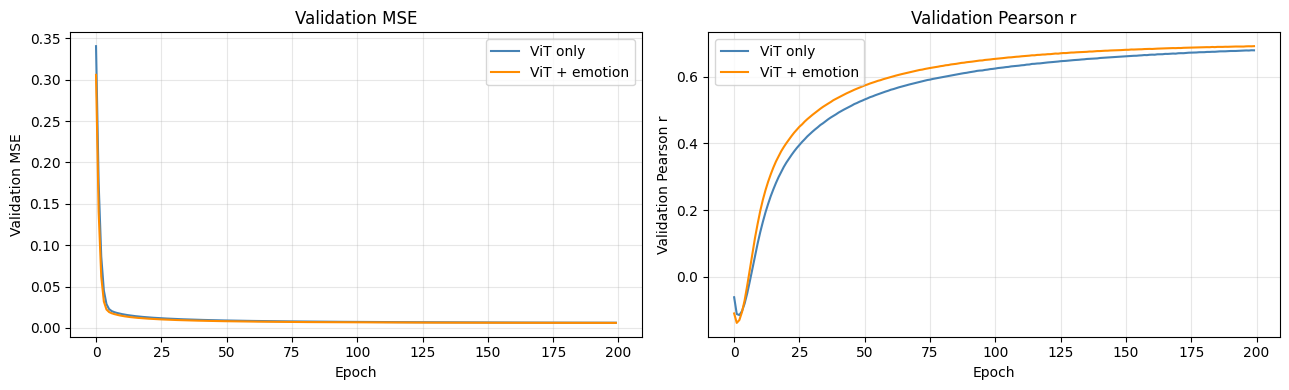

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, label in zip(
    axes,
    ["val_mse", "val_r"],
    ["Validation MSE", "Validation Pearson r"],
):
    ax.plot(hist_no_emo[metric],   label="ViT only",      color="steelblue")
    ax.plot(hist_with_emo[metric], label="ViT + emotion", color="darkorange")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()

In [ ]:

W_full = model_with_emo.linear.weight.data.cpu().numpy()[0]   # (773,)
b      = model_with_emo.linear.bias.data.cpu().numpy()[0]

vit_weights     = W_full[:768]      # first 768 dims = ViT features
emotion_weights = W_full[768:]      # last 5 dims = emotion

print("Emotion weights (raw):")
for emo, w in zip(EMOTIONS, emotion_weights):
    print(f"  {emo:12s}  {w:+.6f}")
print(f"  bias          {b:+.6f}")

print(f"\nViT    |weights| — mean: {np.abs(vit_weights).mean():.6f}  "
      f"std: {np.abs(vit_weights).std():.6f}  max: {np.abs(vit_weights).max():.6f}")
print(f"Emotion|weights| — mean: {np.abs(emotion_weights).mean():.6f}  "
      f"std: {np.abs(emotion_weights).std():.6f}  max: {np.abs(emotion_weights).max():.6f}")

Emotion weights (raw):
  amusement     +0.233199
  excitement    +0.227783
  awe           +0.231292
  contentment   +0.231960
  sadness       +0.231259
  bias          +0.223994

ViT    |weights| — mean: 0.057641  std: 0.047195  max: 0.464092
Emotion|weights| — mean: 0.231099  std: 0.001801  max: 0.233199


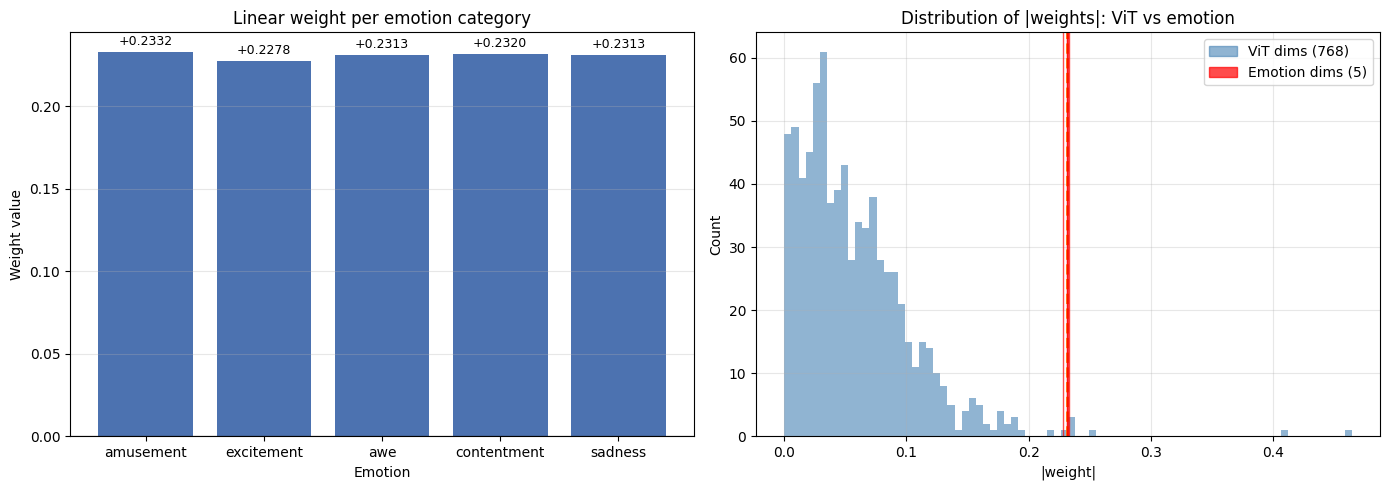

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# emotion weights
ax = axes[0]
colors = ["#4C72B0" if w >= 0 else "#DD8452" for w in emotion_weights]
bars   = ax.bar(EMOTIONS, emotion_weights, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Linear weight per emotion category")
ax.set_ylabel("Weight value")
ax.set_xlabel("Emotion")
for bar, val in zip(bars, emotion_weights):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + np.sign(val) * 0.002,
        f"{val:+.4f}",
        ha="center", va="bottom" if val >= 0 else "top",
        fontsize=9,
    )
ax.grid(axis="y", alpha=0.3)

# distribution of weights: ViT vs emotion
ax2 = axes[1]
ax2.hist(np.abs(vit_weights), bins=80, alpha=0.6, color="steelblue", label="ViT dims (768)")
ax2.axvline(np.abs(emotion_weights).mean(), color="darkorange", linewidth=2,
            linestyle="--", label=f"Emotion mean |w| = {np.abs(emotion_weights).mean():.4f}")
for emo, ew in zip(EMOTIONS, emotion_weights):
    ax2.axvline(abs(ew), color="red", linewidth=1, alpha=0.7)
patch_vit = mpatches.Patch(color="steelblue", alpha=0.6, label="ViT dims (768)")
patch_emo = mpatches.Patch(color="red",       alpha=0.7, label="Emotion dims (5)")
ax2.legend(handles=[patch_vit, patch_emo])
ax2.set_title("Distribution of |weights|: ViT vs emotion")
ax2.set_xlabel("|weight|")
ax2.set_ylabel("Count")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("weight_analysis.png", dpi=150)
plt.show()

In [ ]:
# ── 13. Percentile rank of emotion weights among all weights ─────────────────
#
# If emotion weights are consistently in the top-N% by magnitude, they are
# contributing meaningfully relative to the ViT features.

all_abs = np.abs(W_full)
for emo, ew in zip(EMOTIONS, emotion_weights):
    pct = float((all_abs < abs(ew)).mean()) * 100
    print(f"  {emo:12s}  |w|={abs(ew):.5f}  percentile rank = {pct:.1f}%")

  amusement     |w|=0.23320  percentile rank = 99.2%
  excitement    |w|=0.22778  percentile rank = 98.4%
  awe           |w|=0.23129  percentile rank = 98.7%
  contentment   |w|=0.23196  percentile rank = 99.0%
  sadness       |w|=0.23126  percentile rank = 98.6%


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


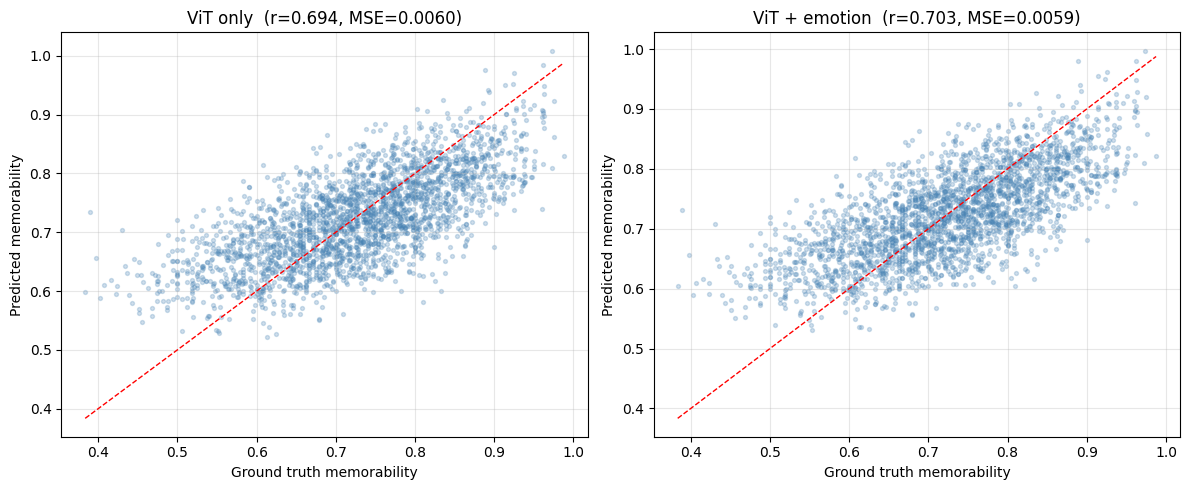

In [ ]:
# ── 14. Scatter plot — predictions vs. ground truth (test set) ───────────────
def get_preds(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.append(model(x.to(DEVICE)).cpu().numpy())
            targets.append(y.numpy())
    return np.concatenate(preds), np.concatenate(targets)

_, _, test_loader_no  = make_loaders(False)
_, _, test_loader_emo = make_loaders(True)

p_no,  t_no  = get_preds(model_no_emo,   test_loader_no)
p_emo, t_emo = get_preds(model_with_emo, test_loader_emo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, targets, title in [
    (axes[0], p_no,  t_no,  "ViT only"),
    (axes[1], p_emo, t_emo, "ViT + emotion"),
]:
    ax.scatter(targets, preds, alpha=0.25, s=8, color="steelblue")
    lo, hi = targets.min(), targets.max()
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    r, _   = pearsonr(preds, targets)
    mse    = np.mean((preds - targets) ** 2)
    ax.set_title(f"{title}  (r={r:.3f}, MSE={mse:.4f})")
    ax.set_xlabel("Ground truth memorability")
    ax.set_ylabel("Predicted memorability")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("scatter_predictions.png", dpi=150)
plt.show()

In [ ]:
SAVE_DIR = f"{ROOT_DIR}/memorability_models"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model_no_emo.state_dict(),   f"{SAVE_DIR}/probe_vit_only.pt")
torch.save(model_with_emo.state_dict(), f"{SAVE_DIR}/probe_vit_emotion.pt")

summary = {
    "vit_only"    : {"test_mse": hist_no_emo["test_mse"],   "test_r": hist_no_emo["test_r"]},
    "vit_emotion" : {"test_mse": hist_with_emo["test_mse"], "test_r": hist_with_emo["test_r"]},
    "emotion_weights": dict(zip(EMOTIONS, emotion_weights.tolist())),
    "emotion_weight_percentiles": {
        emo: float((np.abs(W_full) < abs(ew)).mean()) * 100
        for emo, ew in zip(EMOTIONS, emotion_weights)
    },
}
with open(f"{SAVE_DIR}/results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved models and summary to:", SAVE_DIR)
print(json.dumps(summary, indent=2))

Saved models and summary to: /content/drive/MyDrive/CompNeuroscience-P1/memorability_models
{
  "vit_only": {
    "test_mse": 0.006037971004843712,
    "test_r": 0.6944284439086914
  },
  "vit_emotion": {
    "test_mse": 0.005889091175049543,
    "test_r": 0.7034351825714111
  },
  "emotion_weights": {
    "amusement": 0.23319905996322632,
    "excitement": 0.22778280079364777,
    "awe": 0.23129187524318695,
    "contentment": 0.23196014761924744,
    "sadness": 0.2312585860490799
  },
  "emotion_weight_percentiles": {
    "amusement": 99.22380336351875,
    "excitement": 98.44760672703752,
    "awe": 98.70633893919793,
    "contentment": 98.96507115135834,
    "sadness": 98.57697283311772
  }
}
